# 07 P-threshold Comparison - Centrality vs Embeddings

Compare saved test metrics from the centrality-measure approach and the embedding approach across p-thresholds.

This notebook does not retrain models. It reads the saved metrics from notebooks 04b and 05d.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_squared_error, mean_absolute_error

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')


PROJECT_ROOT = find_project_root()

CENTRALITY_METRICS_PATH = PROJECT_ROOT / 'src' / 'data' / 'predictions' / 'dataset_1' / 'centrality_threshold' / 'metrics.csv'
EMBEDDING_METRICS_PATH = PROJECT_ROOT / 'src' / 'data' / 'predictions' / 'dataset_1' / 'embedding_threshold' / 'metrics.csv'
OUT_DIR = PROJECT_ROOT / 'src' / 'data' / 'predictions' / 'comparison'
OUT_DIR.mkdir(parents=True, exist_ok=True)

P_ORDER = ['p0', 'p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40']
DATASET_P_ORDER = {
    'dataset1': P_ORDER,
    'dataset2': P_ORDER,
    'dataset3': P_ORDER,
}
P_RANK = {p: i for i, p in enumerate(P_ORDER)}
APPROACHES = ['Centrality', 'Embeddings', 'Average', 'Weighted average']
PRED = PROJECT_ROOT / 'src' / 'data' / 'predictions'
APPROACHES = ['Centrality', 'Embeddings', 'Average', 'Weighted average']
PRED = PROJECT_ROOT / 'src' / 'data' / 'predictions'
ROUND_DECIMALS = 3

REQUIRED_COLS = [
    'dataset', 'experiment', 'test_rmse', 'test_mae',
    'test_top1_rmse', 'test_top1_mae',
]

pd.set_option('display.max_columns', 120)
print(PROJECT_ROOT)

/Users/rubenmarques/Documents/Repositórios/Thesis


## Load and clean saved metrics

In [2]:
def load_metrics(path, approach):
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    missing = [col for col in REQUIRED_COLS if col not in df.columns]
    if missing:
        raise ValueError(f'{path.name} missing required columns: {missing}')
    df = df.copy()
    df['approach'] = approach
    return df


centrality = load_metrics(CENTRALITY_METRICS_PATH, 'Centrality')
embeddings = load_metrics(EMBEDDING_METRICS_PATH, 'Embeddings')

combined = pd.concat([centrality, embeddings], ignore_index=True, sort=False)
combined['dataset_group'] = combined['dataset'].str.extract(r'^(dataset[12])')[0]
combined['p'] = combined['dataset'].str.extract(r'_(p\d+)$')[0]
combined.loc[combined['dataset'].str.endswith('_baseline'), 'p'] = 'p0'
combined['p_num'] = combined['p'].map(P_RANK)

# Dataset 1 keeps its own model from 04b/05d (those apply d1's selected model to d1).
keep = (
    ((combined['dataset_group'] == 'dataset1') & (combined['approach'] == 'Centrality') & (combined['experiment'] == 'dataset1_temporal_train_04a_specs')) |
    ((combined['dataset_group'] == 'dataset1') & (combined['approach'] == 'Embeddings') & (combined['experiment'] == 'dataset1_temporal_train_05a_specs'))
)
comparison = combined.loc[keep].copy()
comparison = comparison[comparison.apply(lambda row: row['p'] in DATASET_P_ORDER[row['dataset_group']], axis=1)].copy()


# --- Dataset 2 & 3: centrality vs embeddings from each dataset's OWN threshold metrics ---
def _load_threshold(dsg, ds, approach, sub):
    m = pd.read_csv(PRED / ds / sub / 'metrics.csv')[['p', 'test_rmse', 'test_mae']].copy()
    m['approach'] = approach
    m['dataset_group'] = dsg
    m['experiment'] = f'{ds}_{sub}'
    m['model'] = ''
    m['p_num'] = m['p'].map(P_RANK)
    m['test_top1_rmse'] = np.nan
    m['test_top1_mae'] = np.nan
    return m


# --- Average + Stacked (ensemble) for every dataset ---
def _d1_ensemble(method_src, approach):
    f = PRED / 'dataset_1' / 'hybrid_approach' / 'metrics.csv'
    e = pd.read_csv(f)
    e = e[(e['dataset_group'] == 'dataset1') & (e['method'] == method_src)].copy()
    e['approach'] = approach
    e['dataset_group'] = 'dataset1'
    e['experiment'] = 'dataset1_ensemble'
    e['model'] = ''
    e['p_num'] = e['p'].map(P_RANK)
    return e[['p', 'approach', 'dataset_group', 'experiment', 'model', 'p_num',
              'test_rmse', 'test_mae', 'test_top1_rmse', 'test_top1_mae']]


def _static_ensemble(ds, approach, pred_col):
    pe = pd.read_csv(PRED / ds / 'hybrid_approach' / 'predictions.csv')
    pe = pe[pe['split'] == 'test']
    rows = []
    for pv, g in pe.groupby('p'):
        rows.append({'p': pv, 'approach': approach, 'dataset_group': ds.replace('dataset_', 'dataset'),
                     'experiment': f'{ds}_ensemble', 'model': '', 'p_num': P_RANK.get(pv),
                     'test_rmse': mean_squared_error(g['log_systemic_risk_label'], g[pred_col]) ** 0.5,
                     'test_mae': mean_absolute_error(g['log_systemic_risk_label'], g[pred_col]),
                     'test_top1_rmse': np.nan, 'test_top1_mae': np.nan})
    return pd.DataFrame(rows)


comparison = pd.concat([
    comparison,
    _load_threshold('dataset2', 'dataset_2', 'Centrality', 'centrality_threshold'),
    _load_threshold('dataset2', 'dataset_2', 'Embeddings', 'embedding_threshold'),
    _load_threshold('dataset3', 'dataset_3', 'Centrality', 'centrality_threshold'),
    _load_threshold('dataset3', 'dataset_3', 'Embeddings', 'embedding_threshold'),
    _d1_ensemble('Average', 'Average'),
    _d1_ensemble('Weighted average', 'Weighted average'),
    _static_ensemble('dataset_2', 'Average', 'average_pred'),
    _static_ensemble('dataset_2', 'Weighted average', 'stacked_pred'),
    _static_ensemble('dataset_3', 'Average', 'average_pred'),
    _static_ensemble('dataset_3', 'Weighted average', 'stacked_pred'),
], ignore_index=True, sort=False)

comparison = comparison.sort_values(['dataset_group', 'approach', 'p_num']).reset_index(drop=True)
metric_cols = [col for col in comparison.columns if any(name in col for name in ['rmse', 'mae', 'r2'])]
comparison[metric_cols] = comparison[metric_cols].round(ROUND_DECIMALS)

for dataset_group in ['dataset1', 'dataset2', 'dataset3']:
    for approach in APPROACHES:
        got = comparison.loc[(comparison['dataset_group'] == dataset_group) & (comparison['approach'] == approach), 'p'].tolist()
        expected = DATASET_P_ORDER[dataset_group]
        if got != expected:
            raise ValueError(f'{dataset_group} {approach} has p {got}, expected {expected}')

combined_path = OUT_DIR / 'combined_metrics.csv'
comparison.to_csv(combined_path, index=False)
print(f'Saved combined metrics: {combined_path}')
display(comparison[['approach', 'dataset_group', 'p', 'test_rmse', 'test_mae', 'test_top1_rmse', 'test_top1_mae']])

Saved combined metrics: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/comparison/combined_metrics.csv


,approach,dataset_group,p,test_rmse,test_mae,test_top1_rmse,test_top1_mae
0,Average,dataset1,p0,0.105,0.017,0.883,0.758
1,Average,dataset1,p5,0.094,0.024,0.743,0.643
2,Average,dataset1,p10,0.122,0.019,1.046,0.890
3,Average,dataset1,p15,0.090,0.023,0.664,0.532
4,Average,dataset1,p20,0.081,0.020,0.526,0.438
...,...,...,...,...,...,...,...
103,Weighted average,dataset3,p20,0.317,0.154,NaN,NaN
104,Weighted average,dataset3,p25,0.319,0.156,NaN,NaN
105,Weighted average,dataset3,p30,0.318,0.151,NaN,NaN
106,Weighted average,dataset3,p35,0.318,0.152,NaN,NaN


## Plot helpers

In [3]:
METRIC_PANELS = [
    ('test_rmse', 'Test RMSE'),
    ('test_mae', 'Test MAE'),
    ('test_top1_rmse', 'Top 1% test RMSE'),
    ('test_top1_mae', 'Top 1% test MAE'),
]

APPROACH_COLORS = {
    'Centrality': '#238b45',
    'Embeddings': '#2171b5',
    'Average':    '#d94801',
    'Weighted average':    '#6a51a3',
}

# Which embedding model + ML model produced each dataset's base predictions
# (centrality model | embedding + ML model). Shown as a caption on every plot.
MODEL_INFO = {
    'dataset1': 'Centrality: Gradient Boosting (tuned)  |  Embeddings: graphsage_v1_32 + MLP (tuned)',
    'dataset2': 'Centrality: XGBoost (tuned)  |  Embeddings: graphsage_v1_64 + MLP (tuned)',
    'dataset3': 'Centrality: XGBoost (tuned)  |  Embeddings: node2vec_v2_32 + MLP (tuned)',
}


def _titled(fig, dataset_group, title):
    """Set the figure title + an italic caption naming the models used."""
    fig.suptitle(title, fontsize=14, y=1.0)
    fig.text(0.5, 0.965, MODEL_INFO.get(dataset_group, ''), ha='center', va='top',
             fontsize=9, style='italic', color='#444444')


def _approaches_in(dataset_df):
    present = set(dataset_df['approach'])
    return [a for a in APPROACHES if a in present]


def build_summary_table(dataset_df):
    dataset_group = dataset_df['dataset_group'].iloc[0]
    p_order = DATASET_P_ORDER[dataset_group]
    approaches = _approaches_in(dataset_df)
    rmse = dataset_df.pivot_table(index='p', columns='approach', values='test_rmse').reindex(p_order)[approaches]
    mae = dataset_df.pivot_table(index='p', columns='approach', values='test_mae').reindex(p_order)[approaches]
    rows = []
    for p in p_order:
        row = {'p': p}
        for a in approaches:
            row[f'{a.lower()}_test_rmse'] = rmse.loc[p, a]
        for a in approaches:
            row[f'{a.lower()}_test_mae'] = mae.loc[p, a]
        row['winner_test_rmse'] = rmse.loc[p].idxmin()
        rows.append(row)
    summary = pd.DataFrame(rows)
    num = summary.select_dtypes(include='number').columns
    summary[num] = summary[num].round(ROUND_DECIMALS)
    return summary


def plot_dataset_comparison(comparison_df, dataset_group, title, output_filename):
    dataset_df = comparison_df[comparison_df['dataset_group'] == dataset_group].copy().sort_values('p_num')
    approaches = _approaches_in(dataset_df)
    panels = METRIC_PANELS if dataset_group == 'dataset1' else [p for p in METRIC_PANELS if 'top1' not in p[0]]
    nrows, ncols = (2, 2) if len(panels) == 4 else (1, 2)
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows), sharex=True)
    axes = axes.ravel()
    for ax, (metric_col, metric_title) in zip(axes, panels):
        for approach in approaches:
            group = dataset_df[dataset_df['approach'] == approach].sort_values('p_num')
            ax.plot(group['p'], group[metric_col], marker='o', linewidth=2, label=approach, color=APPROACH_COLORS[approach])
        ax.set_title(metric_title)
        ax.set_xlabel('p (default threshold)')
        ax.set_ylabel('Error')
        ax.grid(True, alpha=0.3)
        ax.legend()
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    _titled(fig, dataset_group, title)
    output_path = OUT_DIR / output_filename
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved figure: {output_path}')
    summary = build_summary_table(dataset_df)
    display(summary)
    return summary

## Dataset 1 comparison

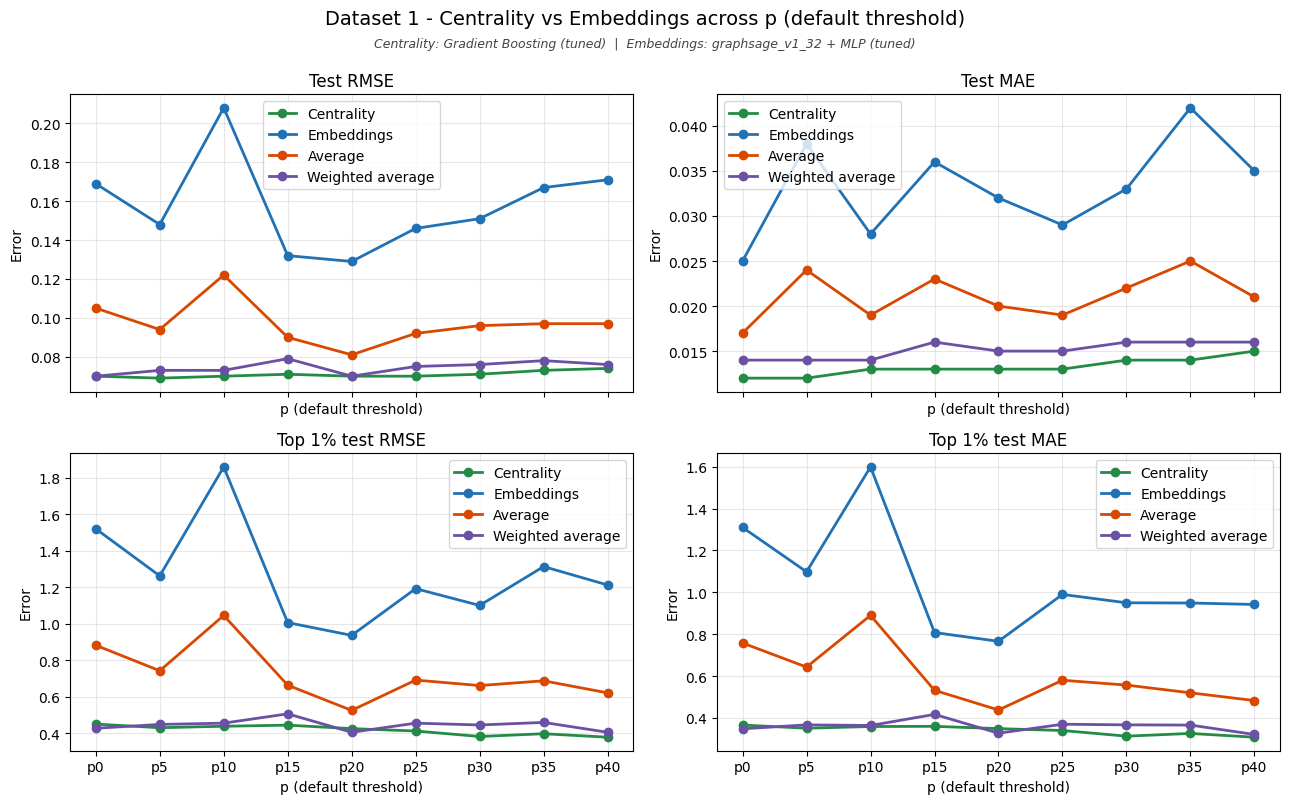

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/comparison/dataset1_p_comparison.png


,p,centrality_test_rmse,embeddings_test_rmse,average_test_rmse,weighted average_test_rmse,centrality_test_mae,embeddings_test_mae,average_test_mae,weighted average_test_mae,winner_test_rmse
0,p0,0.070,0.169,0.105,0.070,0.012,0.025,0.017,0.014,Centrality
1,p5,0.069,0.148,0.094,0.073,0.012,0.038,0.024,0.014,Centrality
2,p10,0.070,0.208,0.122,0.073,0.013,0.028,0.019,0.014,Centrality
3,p15,0.071,0.132,0.090,0.079,0.013,0.036,0.023,0.016,Centrality
4,p20,0.070,0.129,0.081,0.070,0.013,0.032,0.020,0.015,Centrality
5,p25,0.070,0.146,0.092,0.075,0.013,0.029,0.019,0.015,Centrality
6,p30,0.071,0.151,0.096,0.076,0.014,0.033,0.022,0.016,Centrality
7,p35,0.073,0.167,0.097,0.078,0.014,0.042,0.025,0.016,Centrality
8,p40,0.074,0.171,0.097,0.076,0.015,0.035,0.021,0.016,Centrality


In [4]:
dataset1_summary = plot_dataset_comparison(
    comparison,
    dataset_group='dataset1',
    title='Dataset 1 - Centrality vs Embeddings across p (default threshold)',
    output_filename='dataset1_p_comparison.png',
)

## Dataset 2 comparison

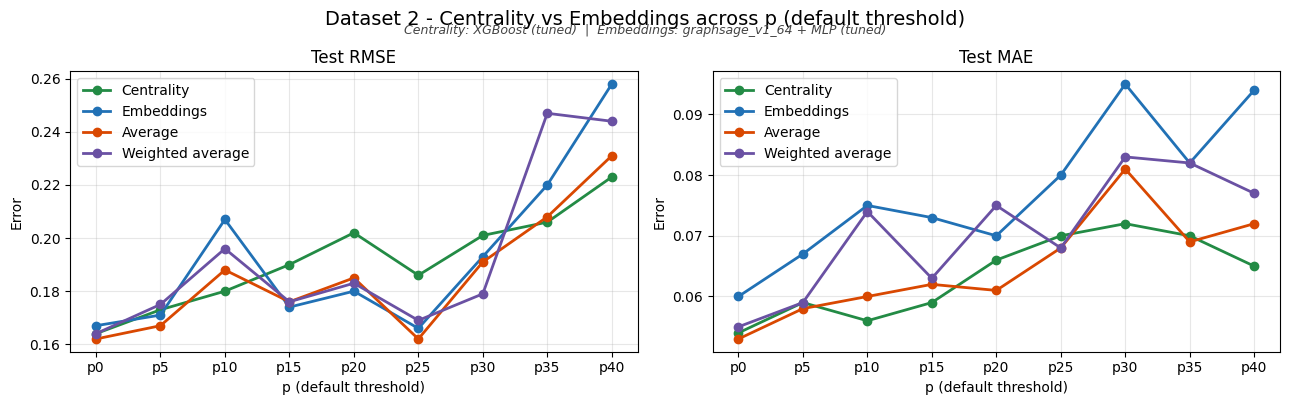

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/comparison/dataset2_p_comparison.png


,p,centrality_test_rmse,embeddings_test_rmse,average_test_rmse,weighted average_test_rmse,centrality_test_mae,embeddings_test_mae,average_test_mae,weighted average_test_mae,winner_test_rmse
0,p0,0.164,0.167,0.162,0.164,0.054,0.060,0.053,0.055,Average
1,p5,0.173,0.171,0.167,0.175,0.059,0.067,0.058,0.059,Average
2,p10,0.180,0.207,0.188,0.196,0.056,0.075,0.060,0.074,Centrality
3,p15,0.190,0.174,0.176,0.176,0.059,0.073,0.062,0.063,Embeddings
4,p20,0.202,0.180,0.185,0.183,0.066,0.070,0.061,0.075,Embeddings
5,p25,0.186,0.166,0.162,0.169,0.070,0.080,0.068,0.068,Average
6,p30,0.201,0.193,0.191,0.179,0.072,0.095,0.081,0.083,Weighted average
7,p35,0.206,0.220,0.208,0.247,0.070,0.082,0.069,0.082,Centrality
8,p40,0.223,0.258,0.231,0.244,0.065,0.094,0.072,0.077,Centrality


In [5]:
dataset2_summary = plot_dataset_comparison(
    comparison,
    dataset_group='dataset2',
    title='Dataset 2 - Centrality vs Embeddings across p (default threshold)',
    output_filename='dataset2_p_comparison.png',
)

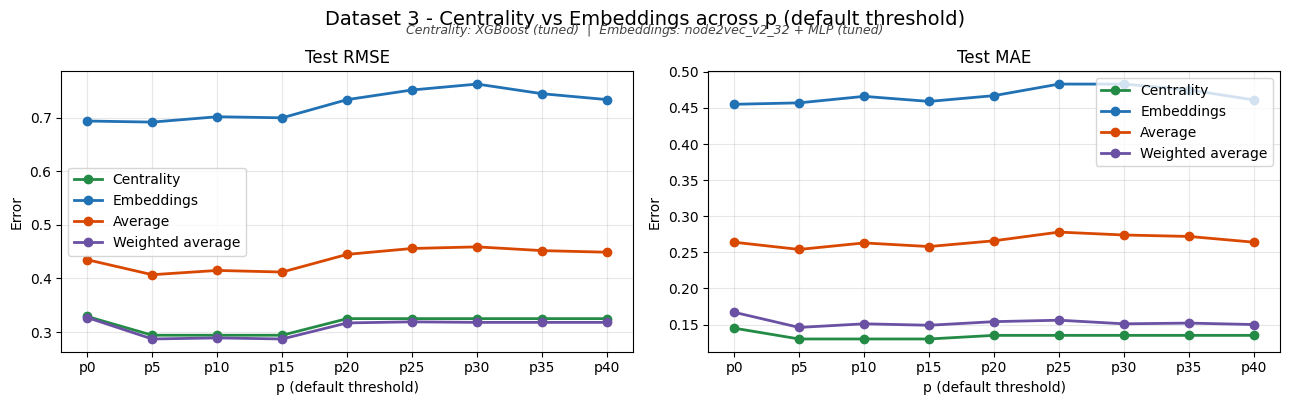

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/comparison/dataset3_p_comparison.png


,p,centrality_test_rmse,embeddings_test_rmse,average_test_rmse,weighted average_test_rmse,centrality_test_mae,embeddings_test_mae,average_test_mae,weighted average_test_mae,winner_test_rmse
0,p0,0.329,0.694,0.435,0.327,0.145,0.455,0.264,0.167,Weighted average
1,p5,0.294,0.692,0.407,0.287,0.130,0.457,0.254,0.146,Weighted average
2,p10,0.294,0.702,0.415,0.289,0.130,0.466,0.263,0.151,Weighted average
3,p15,0.294,0.700,0.412,0.287,0.130,0.459,0.258,0.149,Weighted average
4,p20,0.325,0.734,0.445,0.317,0.135,0.467,0.266,0.154,Weighted average
5,p25,0.325,0.752,0.456,0.319,0.135,0.483,0.278,0.156,Weighted average
6,p30,0.325,0.763,0.459,0.318,0.135,0.483,0.274,0.151,Weighted average
7,p35,0.325,0.745,0.452,0.318,0.135,0.475,0.272,0.152,Weighted average
8,p40,0.325,0.734,0.449,0.318,0.135,0.461,0.264,0.150,Weighted average


In [6]:
dataset3_summary = plot_dataset_comparison(
    comparison,
    dataset_group='dataset3',
    title='Dataset 3 - Centrality vs Embeddings across p (default threshold)',
    output_filename='dataset3_p_comparison.png',
)

## Alternative grouped-bin visualizations

In [7]:
# metric shades (dark -> light) per approach family
COLOR_FAMILIES = {
    'Centrality': ['#005a32', '#238b45', '#74c476', '#c7e9c0'],
    'Embeddings': ['#08306b', '#2171b5', '#6baed6', '#c6dbef'],
    'Average':    ['#7f2704', '#d94801', '#fd8d3c', '#fdd0a2'],
    'Weighted average':    ['#3f007d', '#6a51a3', '#9e9ac8', '#dadaeb'],
}
METRIC_LABELS = [
    ('test_rmse', 'RMSE'),
    ('test_mae', 'MAE'),
    ('test_top1_rmse', 'Top 1% RMSE'),
    ('test_top1_mae', 'Top 1% MAE'),
]
MARKERS = {'Centrality': 'o', 'Embeddings': 's', 'Average': '^', 'Weighted average': 'D'}


def _metrics_for(dataset_group):
    if dataset_group in ('dataset2', 'dataset3'):
        return [m for m in METRIC_LABELS if 'top1' not in m[0]]
    return METRIC_LABELS


def dataset_metric_series(comparison_df, dataset_group, approach, metric_col):
    data = comparison_df[
        (comparison_df['dataset_group'] == dataset_group) &
        (comparison_df['approach'] == approach)
    ].set_index('p').loc[DATASET_P_ORDER[dataset_group]]
    return data[metric_col].to_numpy()


def plot_grouped_bar_metrics(comparison_df, dataset_group, title, output_filename):
    p_order = DATASET_P_ORDER[dataset_group]
    x = np.arange(len(p_order))
    metrics = _metrics_for(dataset_group)
    approaches = _approaches_in(comparison_df[comparison_df['dataset_group'] == dataset_group])
    width = 0.8 / (len(metrics) * len(approaches))
    offset = -0.4 + width / 2
    fig, ax = plt.subplots(figsize=(16, 7))
    for mi, (metric_col, metric_label) in enumerate(metrics):
        for approach in approaches:
            vals = dataset_metric_series(comparison_df, dataset_group, approach, metric_col)
            ax.bar(x + offset, vals, width, label=f'{approach} - {metric_label}', color=COLOR_FAMILIES[approach][mi])
            offset += width
    ax.set_xlabel('p (default threshold) (%)')
    ax.set_ylabel('Error value')
    ax.set_xticks(x)
    ax.set_xticklabels([p.replace('p', '') for p in p_order])
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(title='Approach & metric', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    _titled(fig, dataset_group, title)
    output_path = OUT_DIR / output_filename
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved figure: {output_path}')


def plot_all_metric_lines(comparison_df, dataset_group, title, output_filename):
    p_order = DATASET_P_ORDER[dataset_group]
    x = np.array([int(p.replace('p', '')) for p in p_order])
    metrics = _metrics_for(dataset_group)
    approaches = _approaches_in(comparison_df[comparison_df['dataset_group'] == dataset_group])
    fig, ax = plt.subplots(figsize=(13, 7))
    for mi, (metric_col, metric_label) in enumerate(metrics):
        for approach in approaches:
            vals = dataset_metric_series(comparison_df, dataset_group, approach, metric_col)
            ax.plot(x, vals, marker=MARKERS.get(approach, 'o'), color=COLOR_FAMILIES[approach][mi], label=f'{approach} - {metric_label}')
    ax.set_xlabel('p (default threshold) (%)')
    ax.set_ylabel('Error value')
    ax.set_xticks(x)
    ax.grid(True, alpha=0.3)
    ax.legend(title='Approach & metric', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    _titled(fig, dataset_group, title)
    output_path = OUT_DIR / output_filename
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved figure: {output_path}')

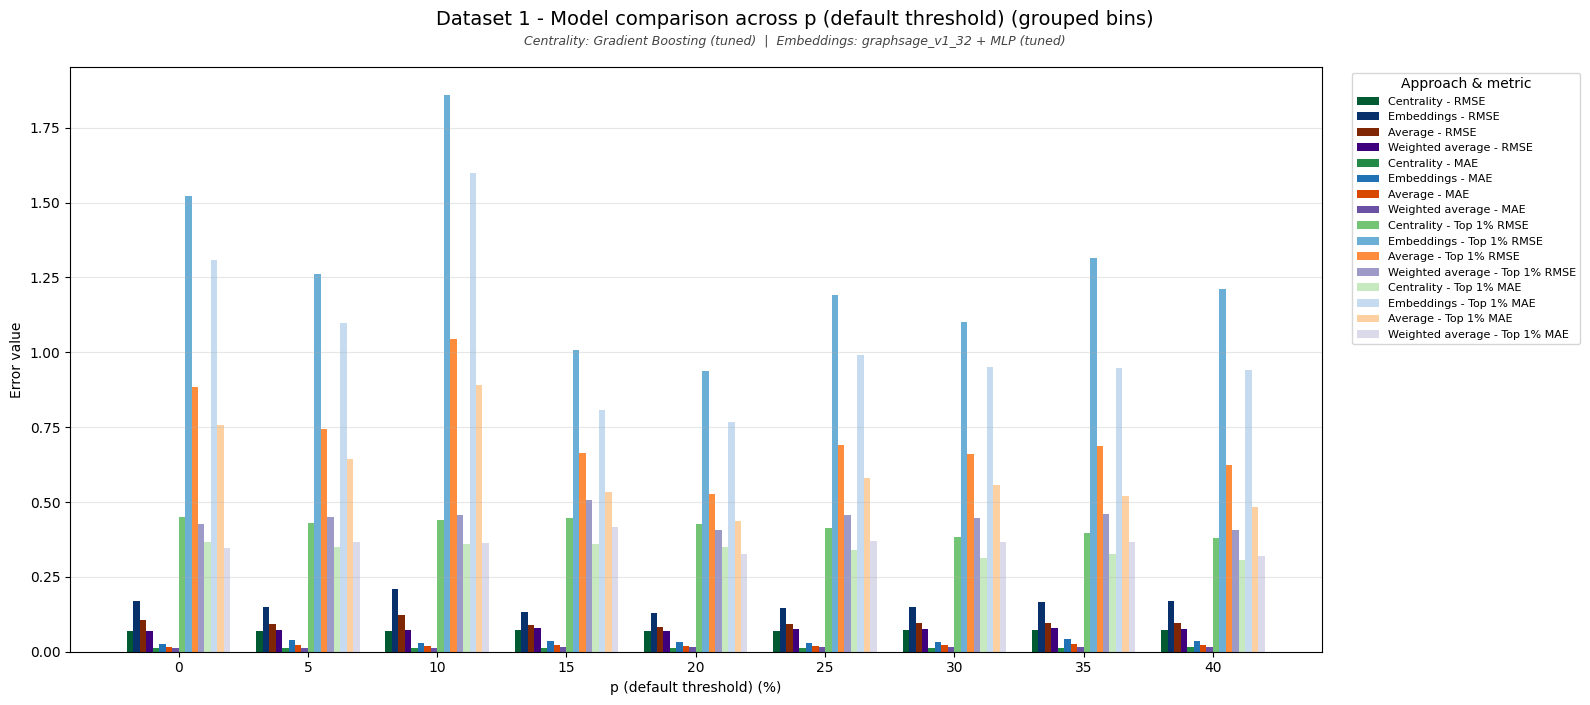

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/comparison/dataset1_grouped_bins_all_metrics.png


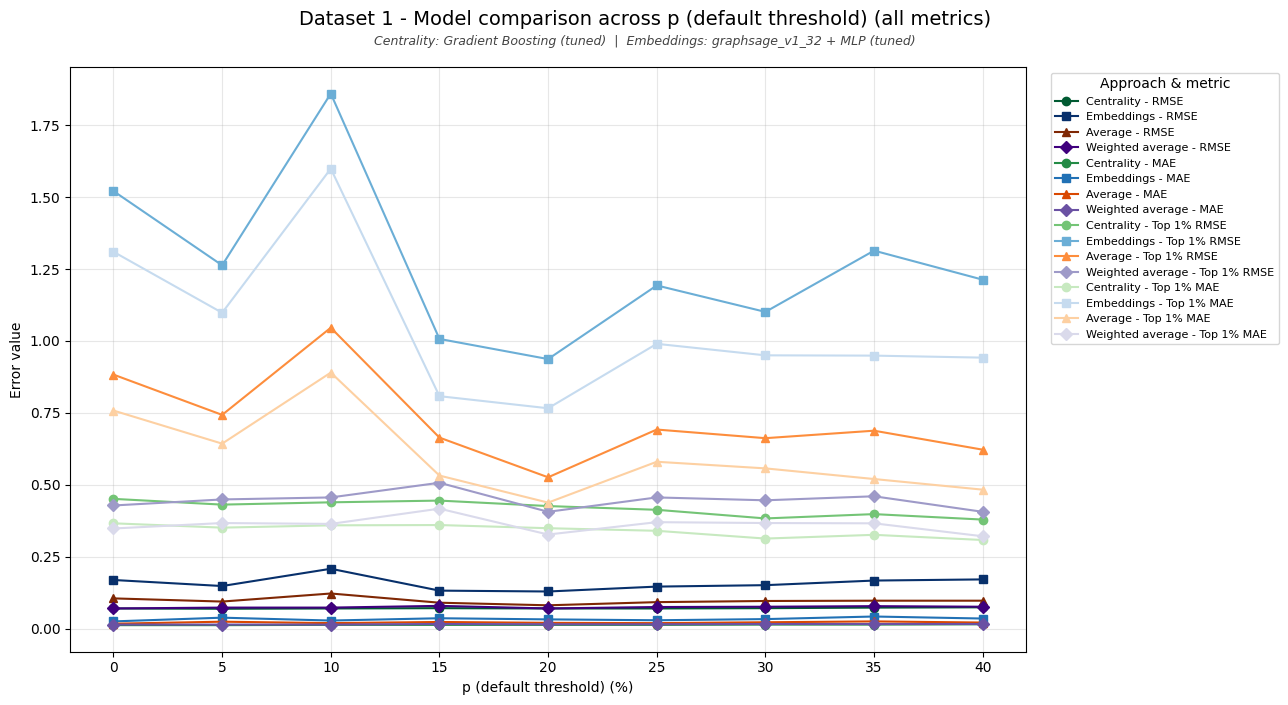

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/comparison/dataset1_lines_all_metrics.png


In [8]:
plot_grouped_bar_metrics(
    comparison,
    dataset_group='dataset1',
    title='Dataset 1 - Model comparison across p (default threshold) (grouped bins)',
    output_filename='dataset1_grouped_bins_all_metrics.png',
)

plot_all_metric_lines(
    comparison,
    dataset_group='dataset1',
    title='Dataset 1 - Model comparison across p (default threshold) (all metrics)',
    output_filename='dataset1_lines_all_metrics.png',
)

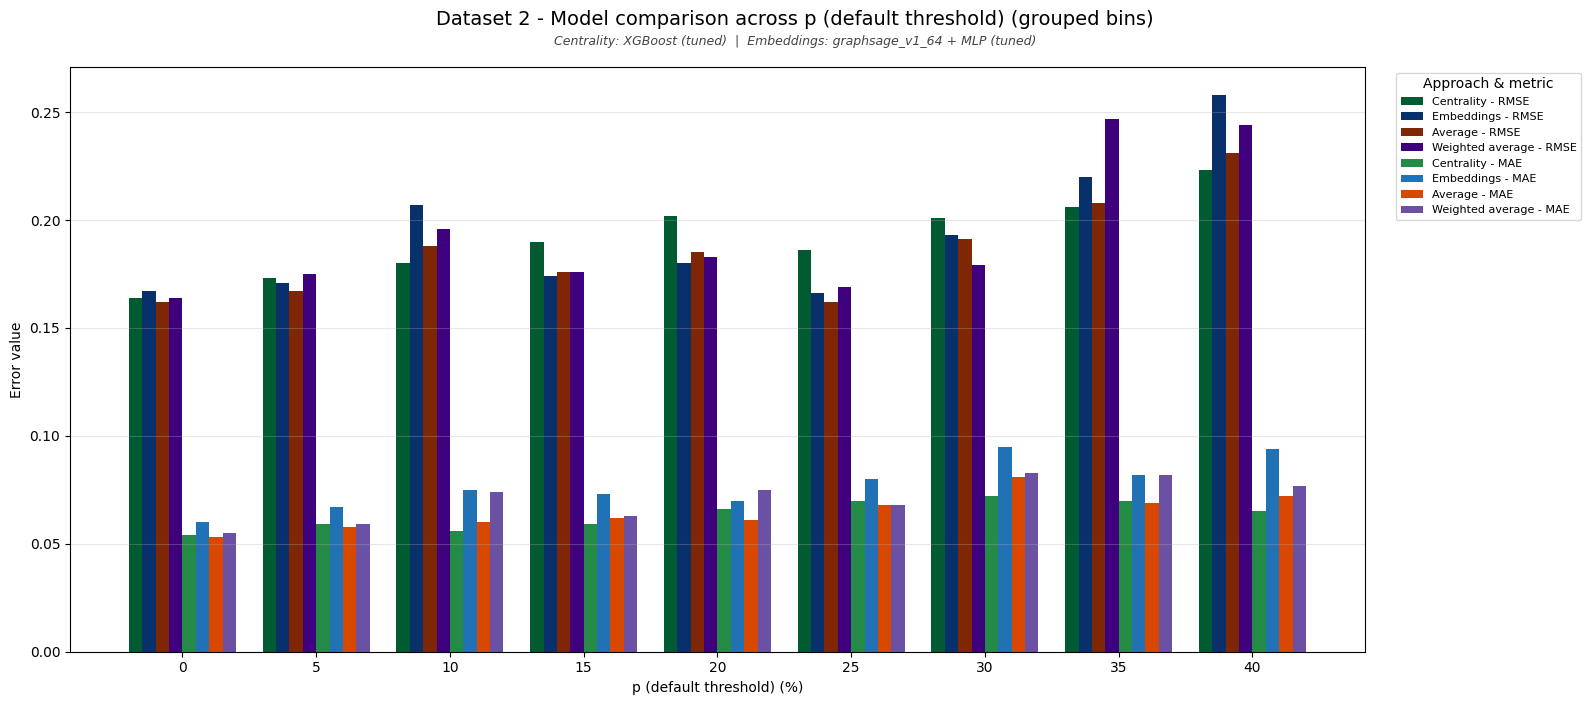

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/comparison/dataset2_grouped_bins_all_metrics.png


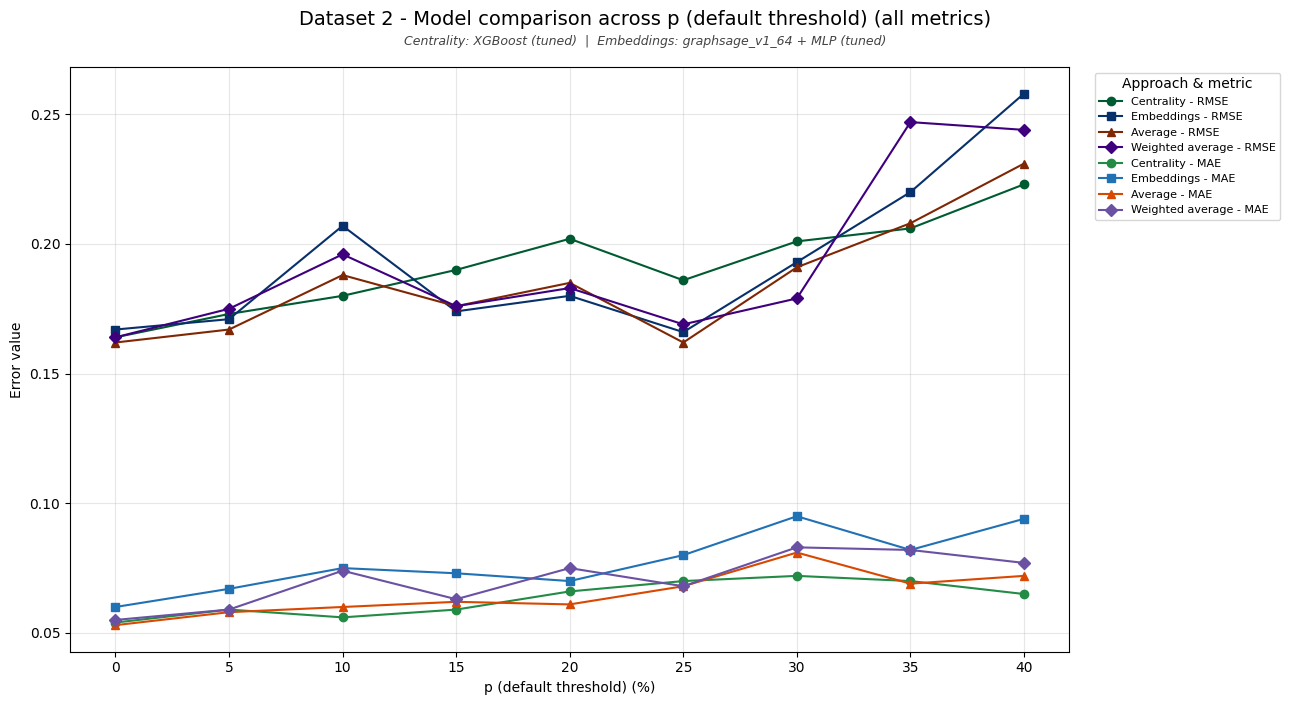

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/comparison/dataset2_lines_all_metrics.png


In [9]:
plot_grouped_bar_metrics(
    comparison,
    dataset_group='dataset2',
    title='Dataset 2 - Model comparison across p (default threshold) (grouped bins)',
    output_filename='dataset2_grouped_bins_all_metrics.png',
)

plot_all_metric_lines(
    comparison,
    dataset_group='dataset2',
    title='Dataset 2 - Model comparison across p (default threshold) (all metrics)',
    output_filename='dataset2_lines_all_metrics.png',
)

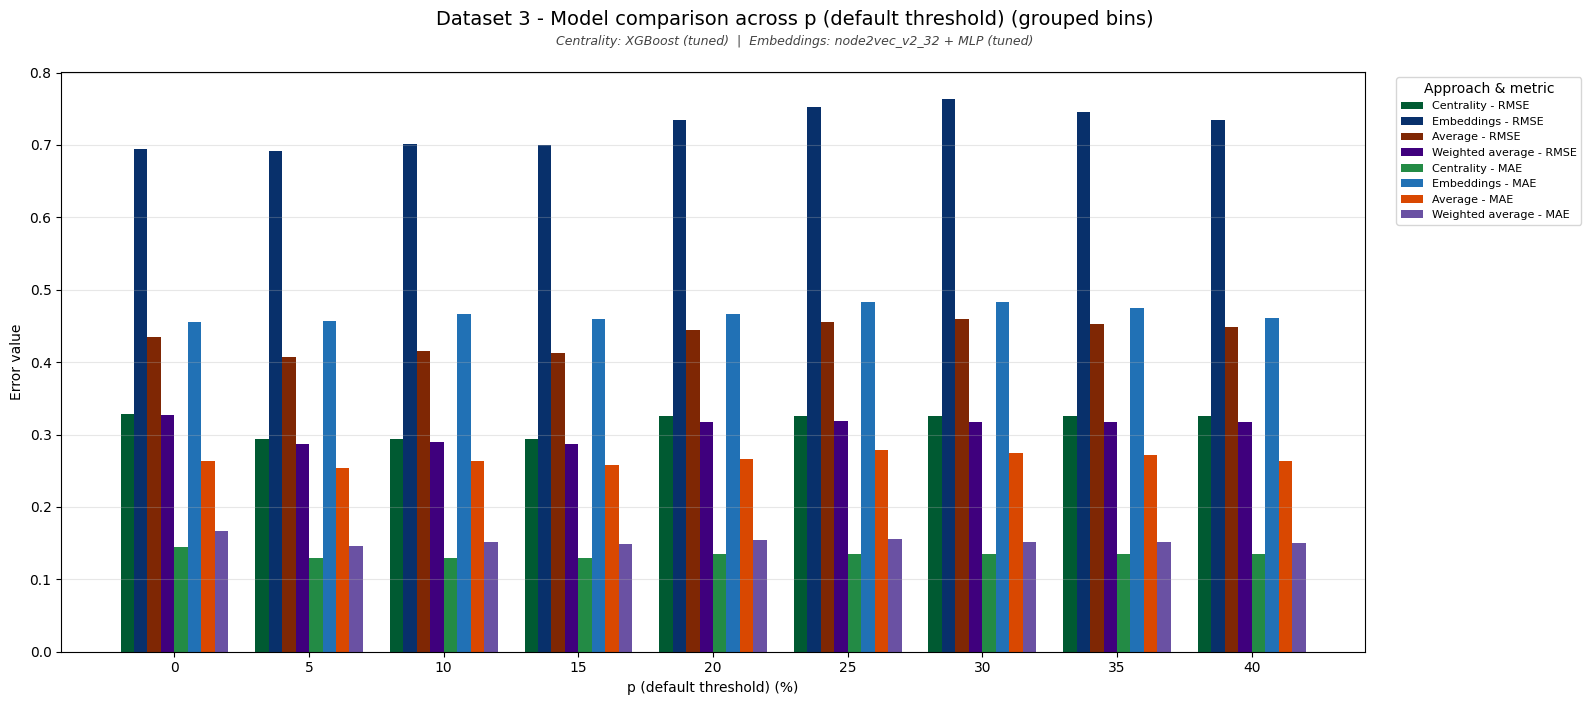

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/comparison/dataset3_grouped_bins_all_metrics.png


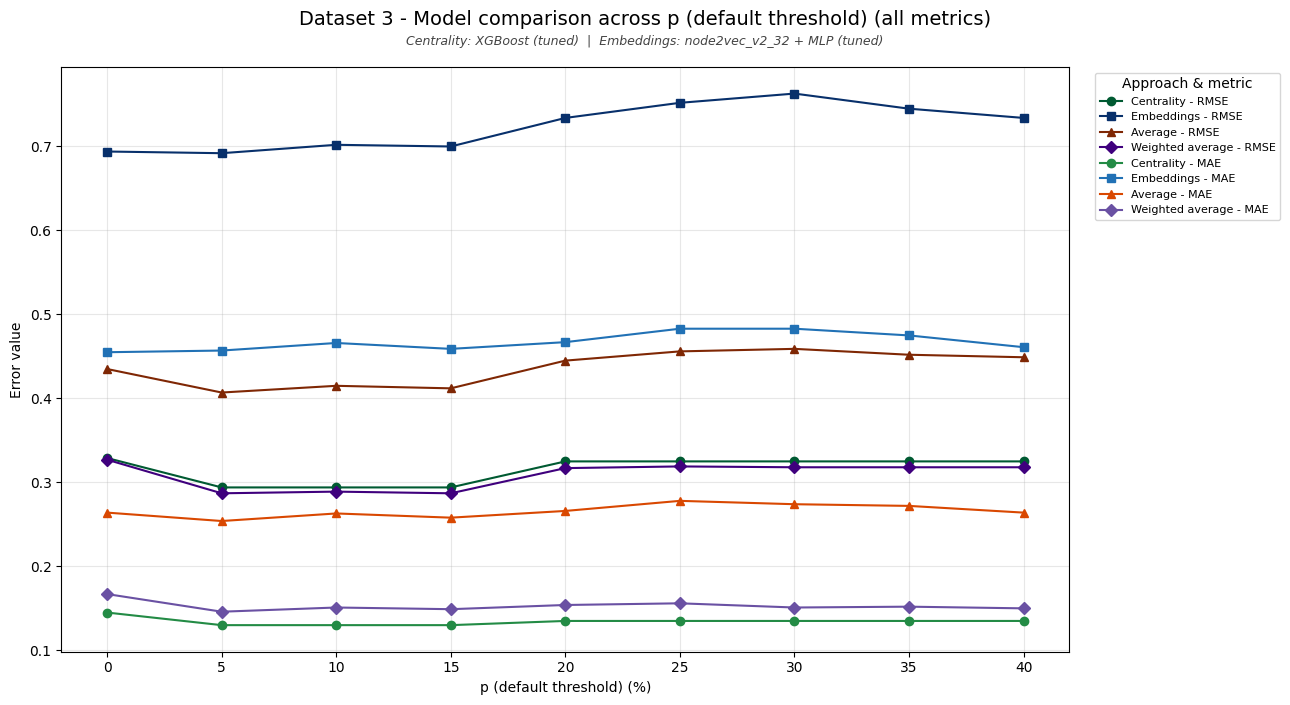

Saved figure: /Users/rubenmarques/Documents/Repositórios/Thesis/src/data/predictions/comparison/dataset3_lines_all_metrics.png


In [10]:
plot_grouped_bar_metrics(
    comparison,
    dataset_group='dataset3',
    title='Dataset 3 - Model comparison across p (default threshold) (grouped bins)',
    output_filename='dataset3_grouped_bins_all_metrics.png',
)

plot_all_metric_lines(
    comparison,
    dataset_group='dataset3',
    title='Dataset 3 - Model comparison across p (default threshold) (all metrics)',
    output_filename='dataset3_lines_all_metrics.png',
)